In [15]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
    balanced_accuracy_score, average_precision_score,
)
from sklearn.preprocessing import label_binarize, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.utils.class_weight import compute_class_weight
from sklearn.exceptions import UndefinedMetricWarning
from xgboost import XGBClassifier
from scipy import stats
import lightgbm as lgb
import joblib, os, json, time, re, warnings
from pathlib import Path

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

# Global style
sns.set_theme(style="whitegrid", palette="deep", font_scale=1.0)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#fafafa",
    "axes.edgecolor": "#333333",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "grid.linestyle": "--",
    "legend.frameon": True,
    "legend.framealpha": 0.9,
    "savefig.bbox": "tight",
})

PALETTE = {
    "primary": "#2c7fb8",
    "accent":  "#e6550d",
    "success": "#31a354",
    "danger":  "#d62728",
    "warning": "#fec44f",
    "neutral": "#636363",
    "purple":  "#756bb1",
}
CLASS_COLORS = {0: "#31a354", 1: "#fec44f", 2: "#d62728"}
CLASS_NAMES = ["LOW", "MEDIUM", "HIGH"]

FIG_DIR   = Path("../figures/classification")
MODEL_DIR = Path("../models")
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(exist_ok=True)

FIG_N = 14  # next figure number

def save_fig(stem):
    global FIG_N
    plt.savefig(FIG_DIR / f"{FIG_N:02d}_{stem}.png", dpi=150, bbox_inches="tight")
    FIG_N += 1

print("Setup complete.")

Setup complete.


In [16]:
train = pd.read_parquet("../data/processed/train.parquet")
val   = pd.read_parquet("../data/processed/val.parquet")
test  = pd.read_parquet("../data/processed/test.parquet")

with open("../models/feature_cols.json") as f:
    meta = json.load(f)
feature_cols = meta["features"]
target_col   = meta["target"]

print(f"Train: {train.shape}  Val: {val.shape}  Test: {test.shape}")
print(f"Features: {len(feature_cols)}  Target base: {target_col}")

Train: (34541, 48)  Val: (7402, 48)  Test: (7402, 48)
Features: 39  Target base: avg_return_temp


In [17]:
LOW_THRESH  = 30.0
HIGH_THRESH = 35.0

def make_risk_label(x):
    if x < LOW_THRESH:      return 0
    elif x <= HIGH_THRESH:  return 1
    else:                   return 2

def add_risk_labels(df, target_col="avg_return_temp"):
    df = df.copy()
    df["next_return_temp"] = df[target_col].shift(-1)
    df["risk"] = df["next_return_temp"].apply(make_risk_label)
    return df.dropna(subset=["next_return_temp", "risk"])

train_r = add_risk_labels(train)
val_r   = add_risk_labels(val)
test_r  = add_risk_labels(test)

print(f"Fixed engineering thresholds:")
print(f"  LOW    < {LOW_THRESH} °C")
print(f"  MEDIUM   {LOW_THRESH} – {HIGH_THRESH} °C")
print(f"  HIGH   > {HIGH_THRESH} °C")

print("\n=== Class distribution ===")
for name, d in [("Train", train_r), ("Val", val_r), ("Test", test_r)]:
    counts = d["risk"].value_counts().sort_index()
    props  = d["risk"].value_counts(normalize=True).sort_index()
    print(f"\n{name}:")
    for i, cname in enumerate(CLASS_NAMES):
        n = int(counts.get(i, 0))
        p = float(props.get(i, 0)) * 100
        print(f"  {cname:8s} {n:6,}  ({p:.2f}%)")

train_p = train_r["risk"].value_counts(normalize=True).sort_index() * 100
test_p  = test_r["risk"].value_counts(normalize=True).sort_index() * 100
shift = pd.DataFrame({
    "train_%": train_p.round(2),
    "test_%":  test_p.round(2),
    "delta_%": (test_p - train_p).round(2),
})
shift.index = [CLASS_NAMES[i] for i in shift.index]
print("\n=== Distribution shift (train vs test) ===")
print(shift)

Fixed engineering thresholds:
  LOW    < 30.0 °C
  MEDIUM   30.0 – 35.0 °C
  HIGH   > 35.0 °C

=== Class distribution ===

Train:
  LOW      11,645  (33.71%)
  MEDIUM   16,537  (47.88%)
  HIGH      6,358  (18.41%)

Val:
  LOW         941  (12.71%)
  MEDIUM    5,574  (75.31%)
  HIGH        886  (11.97%)

Test:
  LOW       2,194  (29.64%)
  MEDIUM    4,915  (66.41%)
  HIGH        292  (3.95%)

=== Distribution shift (train vs test) ===
        train_%  test_%  delta_%
LOW       33.71   29.64    -4.07
MEDIUM    47.88   66.41    18.53
HIGH      18.41    3.95   -14.46


In [18]:
SPLITS = {"train": train_r, "val": val_r, "test": test_r}

def get_ts(d):
    if isinstance(d.index, pd.DatetimeIndex): return d.index
    for c in ("timestamp", "datetime", "time"):
        if c in d.columns: return pd.DatetimeIndex(pd.to_datetime(d[c]))
    return None

def recover_affine():
    u = train["avg_return_temp"].astype(float)
    if 10 < u.mean() < 50 and u.std() > 0.3:
        return 1.0, 0.0, "parquet column already in degC"
    for c in ("avg_return_temp_C", "avg_return_temp_raw"):
        if c in train.columns:
            a, b = np.polyfit(u, train[c].astype(float), 1)
            return float(a), float(b), f"fit against saved column {c}"
    try:
        sc = joblib.load(MODEL_DIR / "scaler.pkl")
        names = list(getattr(sc, "feature_names_in_", []))
        if "avg_return_temp" in names:
            i = names.index("avg_return_temp")
            return float(sc.scale_[i]), float(sc.mean_[i]), "original scaler.pkl"
    except Exception as e:
        print("scaler route failed:", repr(e))
    raise RuntimeError("Cannot recover degC.")

def tier_of(t):
    t = np.asarray(t, dtype=float)
    return np.where(t < LOW_THRESH, 0, np.where(t > HIGH_THRESH, 2, 1))

A_C, B_C, HOW = recover_affine()
to_C = lambda u: A_C * np.asarray(u, dtype=float) + B_C
T_now = {k: to_C(d["avg_return_temp"].values) for k, d in SPLITS.items()}
T_nxt = {k: to_C(d["next_return_temp"].values) for k, d in SPLITS.items()}
print(f"degC recovery: {HOW}  (a={A_C:.5f}, b={B_C:.5f})")

for k, d in SPLITS.items():
    assert np.isfinite(T_now[k]).all() and np.isfinite(T_nxt[k]).all(), f"non-finite values in {k}"
    bad = int((tier_of(T_nxt[k]) != d["risk"].values).sum())
    print(f"{k:5s} label mismatches: {bad}")
    assert bad <= max(2, int(1e-4 * len(d)))

for k, d in SPLITS.items():
    ts = get_ts(d)
    if ts is None:
        print(f"{k:5s} no timestamps found")
        continue
    print(f"{k:5s} {ts.min():%Y-%m-%d} -> {ts.max():%Y-%m-%d}  rows {len(d):>6,}")

def day_ids(d):
    ts = get_ts(d)
    return np.arange(len(d)) // 144 if ts is None else pd.factorize(ts.normalize())[0]

DAY = {k: day_ids(d) for k, d in SPLITS.items()}
IDX_A = np.flatnonzero(DAY["val"] % 2 == 0)
IDX_B = np.flatnonzero(DAY["val"] % 2 == 1)
val_hi = val_r["risk"].values == 2
print(f"val HIGH rows: A={val_hi[IDX_A].sum()}  B={val_hi[IDX_B].sum()}")

degC recovery: parquet column already in degC  (a=1.00000, b=0.00000)
train label mismatches: 0
val   label mismatches: 0
test  label mismatches: 0
train 2023-01-01 -> 2023-09-19  rows 34,540
val   2023-09-19 -> 2023-11-10  rows  7,401
test  2023-11-10 -> 2023-12-31  rows  7,401
val HIGH rows: A=440  B=446


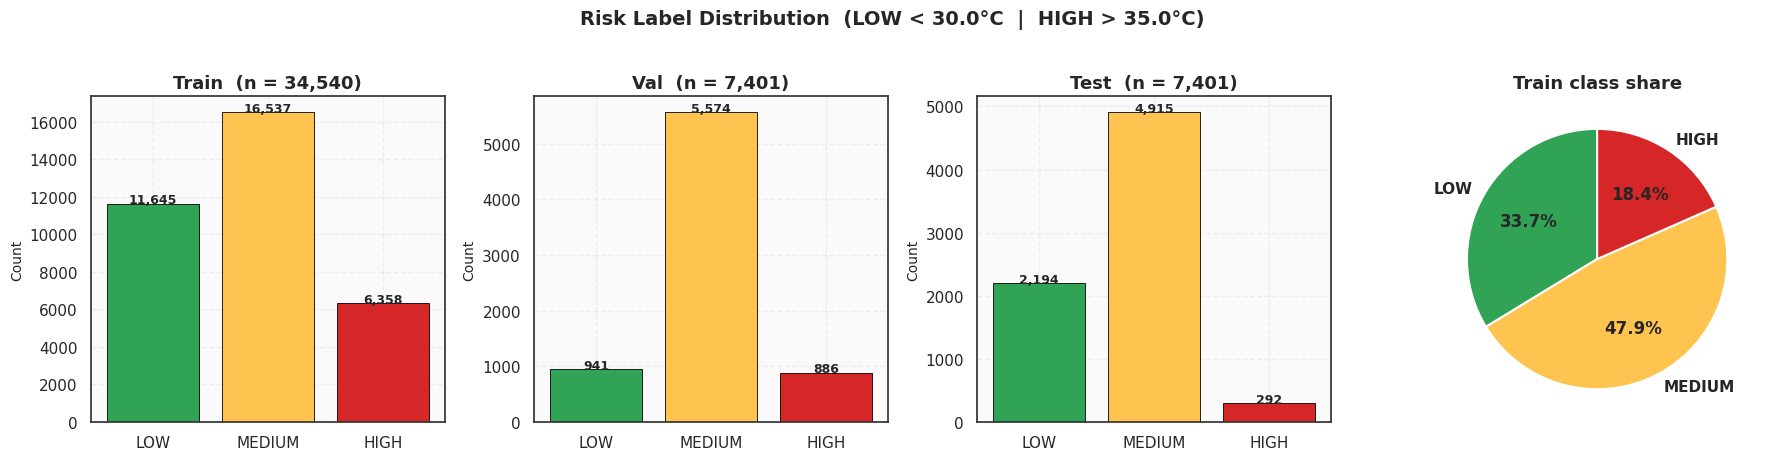

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

splits = [("Train", train_r, PALETTE["primary"]),
          ("Val",   val_r,   PALETTE["accent"]),
          ("Test",  test_r,  PALETTE["danger"])]

for ax, (name, d, c) in zip(axes[:3], splits):
    counts = d["risk"].value_counts().sort_index()
    bars = ax.bar(CLASS_NAMES, counts.values,
                  color=[CLASS_COLORS[i] for i in counts.index],
                  edgecolor="black", linewidth=0.6)
    ax.set_title(f"{name}  (n = {len(d):,})")
    ax.set_ylabel("Count")
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f"{v:,}", ha="center", fontweight="bold", fontsize=9)

ax = axes[3]
counts = train_r["risk"].value_counts().sort_index()
ax.pie(counts.values, labels=CLASS_NAMES, autopct="%1.1f%%",
       colors=[CLASS_COLORS[i] for i in counts.index],
       wedgeprops={"edgecolor": "white", "linewidth": 1.5},
       startangle=90, textprops={"fontweight": "bold"})
ax.set_title("Train class share")

plt.suptitle(f"Risk Label Distribution  (LOW < {LOW_THRESH}°C  |  HIGH > {HIGH_THRESH}°C)",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("class_distribution")
plt.show()

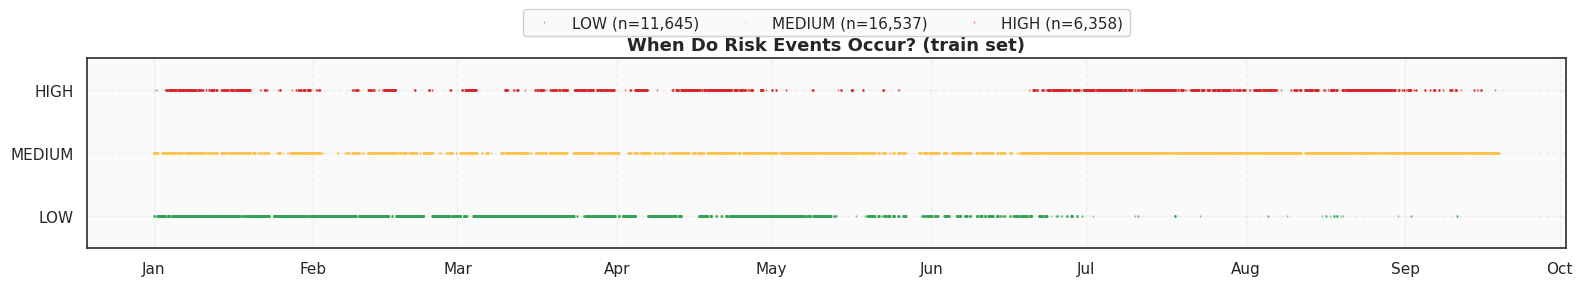

In [20]:
fig, ax = plt.subplots(figsize=(16, 3.2))

for cls, color in CLASS_COLORS.items():
    subset = train_r[train_r["risk"] == cls]
    ax.plot(subset["timestamp"], np.full(len(subset), cls), "|",
            ms=1.5, color=color, alpha=0.6, label=f"{CLASS_NAMES[cls]} (n={len(subset):,})")

ax.set_yticks([0, 1, 2])
ax.set_yticklabels(CLASS_NAMES)
ax.set_ylim(-0.5, 2.5)
ax.set_title("When Do Risk Events Occur? (train set)")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.3))
plt.tight_layout()
save_fig("risk_over_time")
plt.show()

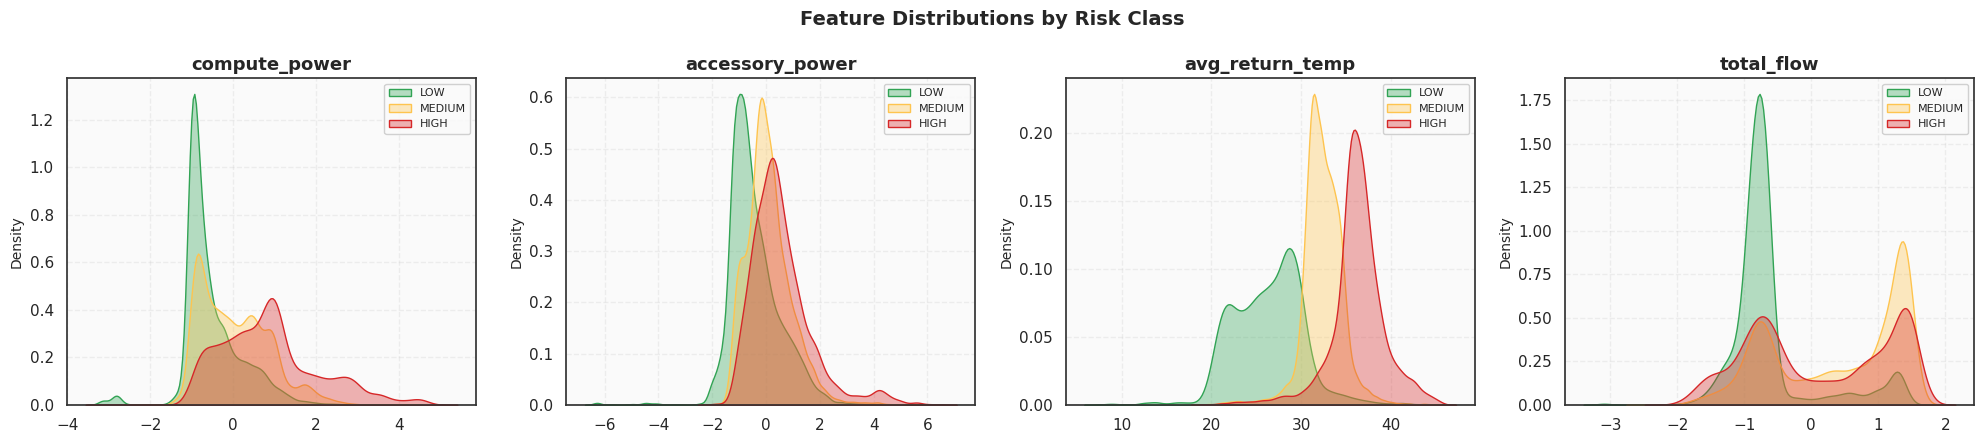

In [23]:
key_feats = ["compute_power", "accessory_power", "avg_return_temp", "total_flow"]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))

for ax, feat in zip(axes, key_feats):
    for cls in [0, 1, 2]:
        sns.kdeplot(train_r.loc[train_r["risk"] == cls, feat],
                    ax=ax, fill=True, alpha=0.35,
                    color=CLASS_COLORS[cls], label=CLASS_NAMES[cls])
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.legend(fontsize=8)

plt.suptitle("Feature Distributions by Risk Class", fontsize=14, fontweight="bold")
plt.tight_layout()
save_fig("class_conditional_dist")
plt.show()

In [24]:
FEAT_BASE = [c for c in feature_cols if c != "avg_return_temp"]
feature_cols = FEAT_BASE + ["avg_return_temp"]
X_train, X_val, X_test = (d[feature_cols] for d in (train_r, val_r, test_r))
y_train, y_val, y_test = (d["risk"].values.astype(int) for d in (train_r, val_r, test_r))

cw = compute_class_weight("balanced", classes=np.arange(3), y=y_train)
models, train_s = {}, {}

def fit_timed(name, m, **kw):
    t0 = time.time()
    m.fit(X_train, y_train, **kw)
    train_s[name] = time.time() - t0
    models[name] = m

fit_timed("LogisticRegression", make_pipeline(StandardScaler(),
          LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)))
fit_timed("RandomForest", RandomForestClassifier(
          n_estimators=300, min_samples_leaf=30, max_features="sqrt",
          class_weight="balanced_subsample", n_jobs=-1, random_state=42))
fit_timed("XGBoost", XGBClassifier(
          n_estimators=300, max_depth=6, learning_rate=0.05,
          eval_metric="mlogloss", tree_method="hist",
          n_jobs=-1, random_state=42), sample_weight=cw[y_train])

print("Feature set size:", len(feature_cols))
print("Training times (s):", {k: round(v, 1) for k, v in train_s.items()})

Feature set size: 40
Training times (s): {'LogisticRegression': 7.0, 'RandomForest': 8.4, 'XGBoost': 7.6}


In [25]:
def scores(y, p):
    y, p = np.asarray(y), np.asarray(p)
    h = y == 2
    tp = int(((p == 2) & h).sum())
    return dict(
        acc=(y == p).mean(),
        bal_acc=balanced_accuracy_score(y, p),
        macro_F1=f1_score(y, p, average="macro"),
        HIGH_recall=tp / max(int(h.sum()), 1),
        HIGH_prec=tp / max(int((p == 2).sum()), 1),
        HIGH_to_LOW=int(((p == 0) & h).sum()) / max(int(h.sum()), 1),
    )

GRID = np.round(np.arange(0.0, 3.001, 0.05), 2)

def margin_table(f, y_hi):
    rows = []
    for m in GRID:
        flag = f >= HIGH_THRESH - m
        rows.append((m, flag[y_hi].mean(), flag[y_hi].sum() / max(flag.sum(), 1), flag[~y_hi].mean()))
    return pd.DataFrame(rows, columns=["margin", "recall", "precision", "fpr"])

def tune_margin(f, y_hi, target):
    t = margin_table(f, y_hi)
    ok = t[t.recall >= target]
    return float((ok.iloc[0] if len(ok) else t.iloc[-1]).margin), t

TARGET_RECALL = 0.80
yB_hi = y_val[IDX_B] == 2
prev = lambda x: np.r_[x[:1], x[:-1]]
rule = lambda f, m: np.where(f >= HIGH_THRESH - m, 2, np.where(f < LOW_THRESH, 0, 1))

f_pers  = {k: T_now[k] for k in SPLITS}
f_trend = {k: T_now[k] + (T_now[k] - prev(T_now[k])) for k in SPLITS}
m_pers,  _ = tune_margin(f_pers["val"][IDX_B],  yB_hi, TARGET_RECALL)
m_trend, _ = tune_margin(f_trend["val"][IDX_B], yB_hi, TARGET_RECALL)
n_pm = f"persistence + {m_pers:.2f}C margin"
n_lt = f"linear trend + {m_trend:.2f}C margin"

BASE_PRED = {
    "majority (MEDIUM)": np.ones(len(y_test), int),
    "persistence":       rule(f_pers["test"], 0.0),
    n_pm:                rule(f_pers["test"], m_pers),
    n_lt:                rule(f_trend["test"], m_trend),
}
BASE_SCORE = {
    "majority (MEDIUM)": np.zeros(len(y_test)),
    "persistence":       f_pers["test"],
    n_pm:                f_pers["test"],
    n_lt:                f_trend["test"],
}

d_te = np.abs(T_nxt["test"] - T_now["test"])
cur = tier_of(T_now["test"])
print("|T(t+1)-T(t)| test percentiles 50/90/99/99.9 (degC):",
      np.round(np.percentile(d_te, [50, 90, 99, 99.9]), 2))
print(f"rows where the tier changes: {(cur != y_test).mean():.2%} | "
      f"HIGH rows whose CURRENT tier is LOW: {((y_test == 2) & (cur == 0)).sum()}")
print(pd.DataFrame({k: scores(y_test, p) for k, p in BASE_PRED.items()}).T.round(3))

|T(t+1)-T(t)| test percentiles 50/90/99/99.9 (degC): [0.39 2.06 5.89 9.53]
rows where the tier changes: 12.44% | HIGH rows whose CURRENT tier is LOW: 23
                               acc  bal_acc  macro_F1  HIGH_recall  HIGH_prec  \
majority (MEDIUM)            0.664    0.333     0.266        0.000      0.000   
persistence                  0.876    0.767     0.767        0.548      0.548   
persistence + 1.60C margin   0.761    0.778     0.644        0.767      0.173   
linear trend + 2.80C margin  0.505    0.660     0.479        0.818      0.076   

                             HIGH_to_LOW  
majority (MEDIUM)                  0.000  
persistence                        0.079  
persistence + 1.60C margin         0.079  
linear trend + 2.80C margin        0.092  


In [26]:
ANNUAL  = re.compile(r"(month|doy|day_?of_?year|week_?of_?year|season|quarter)", re.I)
DIURNAL = re.compile(r"(hour|minute|dow|day_?of_?week|weekday|weekend|_sin$|_cos$|^sin_|^cos_)", re.I)
annual_cols   = [c for c in FEAT_BASE if ANNUAL.search(c)]
calendar_cols = sorted(set(annual_cols) | {c for c in FEAT_BASE if DIURNAL.search(c)})
print("annual  :", annual_cols)
print("calendar:", calendar_cols)

VARIANTS = {
    "all":         feature_cols,
    "no_annual":   [c for c in feature_cols if c not in annual_cols],
    "no_calendar": [c for c in feature_cols if c not in calendar_cols],
}
D = {k: T_nxt[k] - T_now[k] for k in SPLITS}

def fit_forecaster(cols, seed=42, n_estimators=1500):
    reg = lgb.LGBMRegressor(
        n_estimators=n_estimators, learning_rate=0.05, num_leaves=31,
        min_child_samples=50, subsample=0.8, subsample_freq=1,
        colsample_bytree=0.8, reg_lambda=5.0, random_state=seed,
        n_jobs=-1, verbose=-1, deterministic=True, force_row_wise=True,
    )
    reg.fit(X_train[cols].values, D["train"],
            eval_set=[(X_val.iloc[IDX_A][cols].values, D["val"][IDX_A])],
            eval_metric="l1",
            callbacks=[lgb.early_stopping(50, verbose=False)])
    return reg

TA, yA_hi = T_nxt["val"][IDX_A], T_nxt["val"][IDX_A] > HIGH_THRESH
mae_pers = np.abs(D["val"][IDX_A]).mean()
abl = {}
for name, cols_ in VARIANTS.items():
    reg_ = fit_forecaster(cols_)
    f = T_now["val"][IDX_A] + reg_.predict(X_val.iloc[IDX_A][cols_].values)
    mae = np.abs(TA - f).mean()
    abl[name] = dict(
        n_feat=len(cols_),
        trees=reg_.best_iteration_,
        valA_MAE=mae,
        skill_vs_persist=1 - mae / mae_pers,
        valA_AUC_HIGH=roc_auc_score(yA_hi, f),
        valA_AP_HIGH=average_precision_score(yA_hi, f),
    )

abl = pd.DataFrame(abl).T
print(abl.round(4))
print(f"persistence MAE on val-A: {mae_pers:.4f} degC")
best = abl.valA_MAE.min()
FINAL_VARIANT = next(v for v in ["no_calendar", "no_annual", "all"]
                     if abl.loc[v, "valA_MAE"] <= 1.03 * best)
print("chosen on val-A only:", FINAL_VARIANT)

annual  : []
calendar: ['dow_cos', 'dow_sin', 'hour_cos', 'hour_sin']


/home/adity/projects/coolant-project/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/adity/projects/coolant-project/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)
/home/adity/projects/coolant-project/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


             n_feat  trees  valA_MAE  skill_vs_persist  valA_AUC_HIGH  \
all            40.0    2.0    0.9299            0.0041         0.8666   
no_annual      40.0    2.0    0.9299            0.0041         0.8666   
no_calendar    36.0    3.0    0.9310            0.0029         0.8669   

             valA_AP_HIGH  
all                0.6955  
no_annual          0.6955  
no_calendar        0.6961  
persistence MAE on val-A: 0.9337 degC
chosen on val-A only: no_calendar


In [27]:
class ForecastTierClassifier:
    classes_ = np.array([0, 1, 2])

    def __init__(self, reg, cols, all_cols, cur_col, affine, resid_sorted, margin=0.0):
        self.reg, self.cols, self.all_cols = reg, list(cols), list(all_cols)
        self.idx = [self.all_cols.index(c) for c in self.cols]
        self.cur_idx = self.all_cols.index(cur_col)
        self.a, self.b = affine
        self.res, self.margin = np.asarray(resid_sorted), margin

    def _A(self, X):
        return X[self.all_cols].values if hasattr(X, "columns") else np.asarray(X)

    def forecast(self, X):
        M = self._A(X)
        return self.a * M[:, self.cur_idx] + self.b + self.reg.predict(M[:, self.idx])

    def _cdf(self, v):
        return np.searchsorted(self.res, v, side="right") / len(self.res)

    def predict_proba(self, X):
        f = self.forecast(X)
        p_lo = self._cdf(LOW_THRESH - f)
        p_hi = 1.0 - self._cdf(HIGH_THRESH - f)
        return np.column_stack([p_lo, 1.0 - p_lo - p_hi, p_hi])

    def predict(self, X):
        f = self.forecast(X)
        return np.where(f >= HIGH_THRESH - self.margin, 2,
                        np.where(f < LOW_THRESH, 0, 1))

    @property
    def feature_importances_(self):
        imp = np.zeros(len(self.all_cols))
        imp[self.idx] = self.reg.feature_importances_
        return imp / max(imp.sum(), 1)

cols = VARIANTS[FINAL_VARIANT]
t0 = time.time()
reg = fit_forecaster(cols)
train_s["ForecastTier (LGBM dT)"] = time.time() - t0

clf = ForecastTierClassifier(reg, cols, feature_cols, "avg_return_temp",
                             (A_C, B_C), np.array([0.0]))
fB = clf.forecast(X_val.iloc[IDX_B])
clf.res = np.sort(T_nxt["val"][IDX_B] - fB)
clf.margin, tabB = tune_margin(fB, yB_hi, TARGET_RECALL)

r = tabB.loc[(tabB.margin - clf.margin).abs().idxmin()]
print(f"margin {clf.margin:.2f} degC -> val-B recall {r.recall:.3f}, "
      f"precision {r.precision:.3f}, FPR {r.fpr:.4f}")
for tr in (0.7, 0.8, 0.9):
    m_, _ = tune_margin(fB, yB_hi, tr)
    print(f"  target recall {tr:.1f} -> margin {m_:.2f} degC")

for nm, y_ in (("train", y_train), ("val", y_val), ("test", y_test)):
    pi = (y_ == 2).mean()
    prec = r.recall * pi / (r.recall * pi + r.fpr * (1 - pi))
    print(f"  expected HIGH precision at {nm} prevalence {pi:.3f}: {prec:.3f}")

f_test = clf.forecast(X_test)
mae   = np.abs(T_nxt["test"] - f_test).mean()
mae_p = np.abs(T_nxt["test"] - T_now["test"]).mean()
print(f"test forecast MAE {mae:.3f} degC (persistence {mae_p:.3f}, "
      f"skill {1 - mae / mae_p:.1%})")

best_name = "ForecastTier (LGBM dT)"
models[best_name] = clf

/home/adity/projects/coolant-project/.venv/lib/python3.10/site-packages/lightgbm/sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


margin 1.70 degC -> val-B recall 0.800, precision 0.273, FPR 0.2885
  target recall 0.7 -> margin 0.45 degC
  target recall 0.8 -> margin 1.70 degC
  target recall 0.9 -> margin 3.00 degC
  expected HIGH precision at train prevalence 0.184: 0.385
  expected HIGH precision at val prevalence 0.120: 0.274
  expected HIGH precision at test prevalence 0.039: 0.102
test forecast MAE 0.831 degC (persistence 0.822, skill -1.1%)


test HIGH prevalence = 0.0395
                               acc  bal_acc  macro_F1  HIGH_recall  HIGH_prec  HIGH_to_LOW  HIGH_AUC  HIGH_AP  train_s
majority (MEDIUM)            0.664    0.333     0.266        0.000      0.000        0.000     0.500    0.039    0.000
persistence                  0.876    0.767     0.767        0.548      0.548        0.079     0.856    0.482    0.000
persistence + 1.60C margin   0.761    0.778     0.644        0.767      0.173        0.079     0.856    0.482    0.000
linear trend + 2.80C margin  0.505    0.660     0.479        0.818      0.076        0.092     0.824    0.265    0.000
LogisticRegression           0.716    0.664     0.599        0.442      0.270        0.233     0.794    0.253    6.952
RandomForest                 0.858    0.781     0.750        0.610      0.462        0.089     0.863    0.462    8.435
XGBoost                      0.792    0.657     0.656        0.425      0.400        0.137     0.816    0.317    7.634
ForecastTier (LGBM

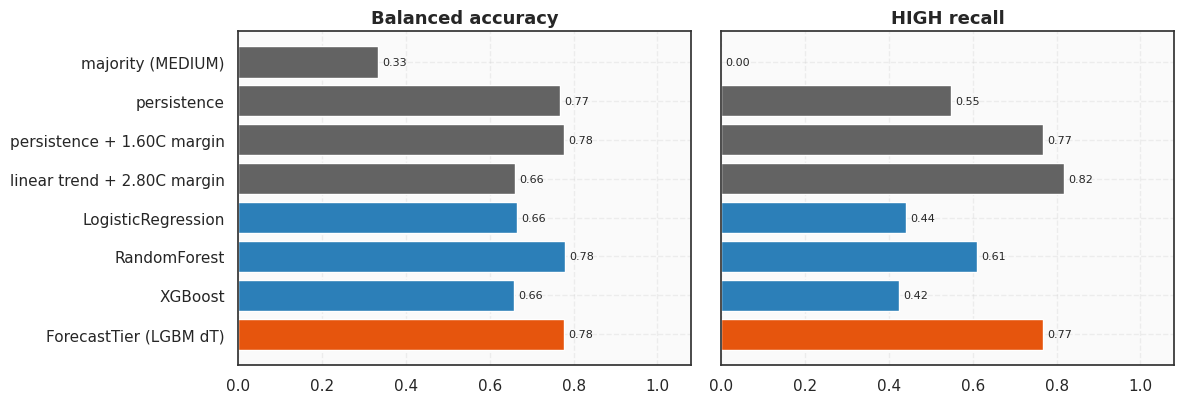

In [28]:
REG = {k: dict(pred=BASE_PRED[k], score=BASE_SCORE[k], train_s=0.0) for k in BASE_PRED}
REG |= {n: dict(pred=np.asarray(m.predict(X_test)).astype(int),
                score=m.predict_proba(X_test)[:, 2],
                train_s=train_s.get(n, np.nan))
        for n, m in models.items()}

def row(name, e):
    s = scores(y_test, e["pred"])
    s["HIGH_AUC"] = roc_auc_score(y_test == 2, e["score"])
    s["HIGH_AP"]  = average_precision_score(y_test == 2, e["score"])
    s["train_s"]  = e["train_s"]
    return pd.Series(s, name=name)

cmp_tbl = pd.DataFrame([row(n, e) for n, e in REG.items()])
print(f"test HIGH prevalence = {(y_test == 2).mean():.4f}")
print(cmp_tbl.round(3).to_string())

colors = [PALETTE["accent"] if n == best_name
          else PALETTE["neutral"] if n in BASE_PRED
          else PALETTE["primary"]
          for n in cmp_tbl.index]

fig, ax = plt.subplots(1, 2, figsize=(12, 4.2), sharey=True)
for a, col, ttl in zip(ax, ["bal_acc", "HIGH_recall"], ["Balanced accuracy", "HIGH recall"]):
    a.barh(cmp_tbl.index, cmp_tbl[col], color=colors)
    a.set_title(ttl); a.set_xlim(0, 1.08)
    for i, v in enumerate(cmp_tbl[col]):
        a.text(v + 0.01, i, f"{v:.2f}", va="center", fontsize=8)
ax[0].invert_yaxis()
plt.tight_layout()
save_fig("model_comparison")
plt.show()

In [29]:
DAYS_T = DAY["test"]
UD = np.unique(DAYS_T)
BY_DAY = {d: np.flatnonzero(DAYS_T == d) for d in UD}
cur_tier = tier_of(T_now["test"])

def boot_ci(fn, y, p, n_boot=300, seed=42):
    rng, out = np.random.default_rng(seed), []
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for _ in range(n_boot):
            idx = np.concatenate([BY_DAY[d] for d in rng.choice(UD, len(UD))])
            out.append(fn(y[idx], p[idx]))
    return np.nanpercentile(out, [2.5, 97.5])

rec_high = lambda y, p: (p[y == 2] == 2).mean() if (y == 2).any() else np.nan

def runs(mask):
    e = np.diff(np.r_[0, mask.astype(np.int8), 0])
    return list(zip(np.flatnonzero(e == 1), np.flatnonzero(e == -1)))

def event_metrics(y, p, pad=3):
    ev = runs(y == 2)
    if not ev:
        return {}
    al = runs(p == 2)
    near = np.convolve((y == 2).astype(int), np.ones(2 * pad + 1, int), "same") > 0
    return dict(
        n_episodes=len(ev),
        episode_detect=np.mean([(p[s:e] == 2).any() for s, e in ev]),
        first_row_detect=np.mean([p[s] == 2 for s, e in ev]),
        alarm_runs=len(al),
        alarm_run_precision=np.mean([near[s:e].any() for s, e in al]) if al else np.nan,
    )

def ext(name, e):
    p, y = e["pred"], y_test
    s = {"HIGH_recall": scores(y, p)["HIGH_recall"]}
    lo, hi = boot_ci(rec_high, y, p);                s["HIGH_recall_CI95"] = f"[{lo:.2f}, {hi:.2f}]"
    lo, hi = boot_ci(balanced_accuracy_score, y, p); s["bal_acc_CI95"]    = f"[{lo:.2f}, {hi:.2f}]"
    s["ordinal_MAE_tiers"] = np.abs(y - p).mean()
    trans = cur_tier != y
    onset = (y == 2) & (cur_tier != 2)
    s["acc_on_tier_changes"] = (p[trans] == y[trans]).mean()
    s["HIGH_onset_recall"]   = (p[onset] == 2).mean() if onset.any() else np.nan
    s.update(event_metrics(y, p))
    return pd.Series(s, name=name)

ext_tbl = pd.DataFrame([ext(n, e) for n, e in REG.items()])
print(f"test days: {len(UD)} | HIGH onset rows: {((y_test == 2) & (cur_tier != 2)).sum()} | "
      f"tier-change rows: {(cur_tier != y_test).sum()}")
print(ext_tbl.round(3).T.to_string())

test days: 52 | HIGH onset rows: 132 | tier-change rows: 921
                    majority (MEDIUM)   persistence persistence + 1.60C margin linear trend + 2.80C margin LogisticRegression  RandomForest       XGBoost ForecastTier (LGBM dT)
HIGH_recall                       0.0         0.548                      0.767                       0.818              0.442          0.61         0.425                  0.767
HIGH_recall_CI95         [0.00, 0.00]  [0.44, 0.64]               [0.65, 0.85]                [0.72, 0.89]       [0.30, 0.53]  [0.50, 0.69]  [0.27, 0.52]           [0.64, 0.85]
bal_acc_CI95             [0.33, 0.33]  [0.73, 0.80]               [0.73, 0.81]                [0.62, 0.69]       [0.61, 0.70]  [0.74, 0.81]  [0.59, 0.70]           [0.73, 0.81]
ordinal_MAE_tiers               0.336         0.129                      0.247                       0.518              0.296          0.15         0.221                  0.245
acc_on_tier_changes             0.481           0.0   

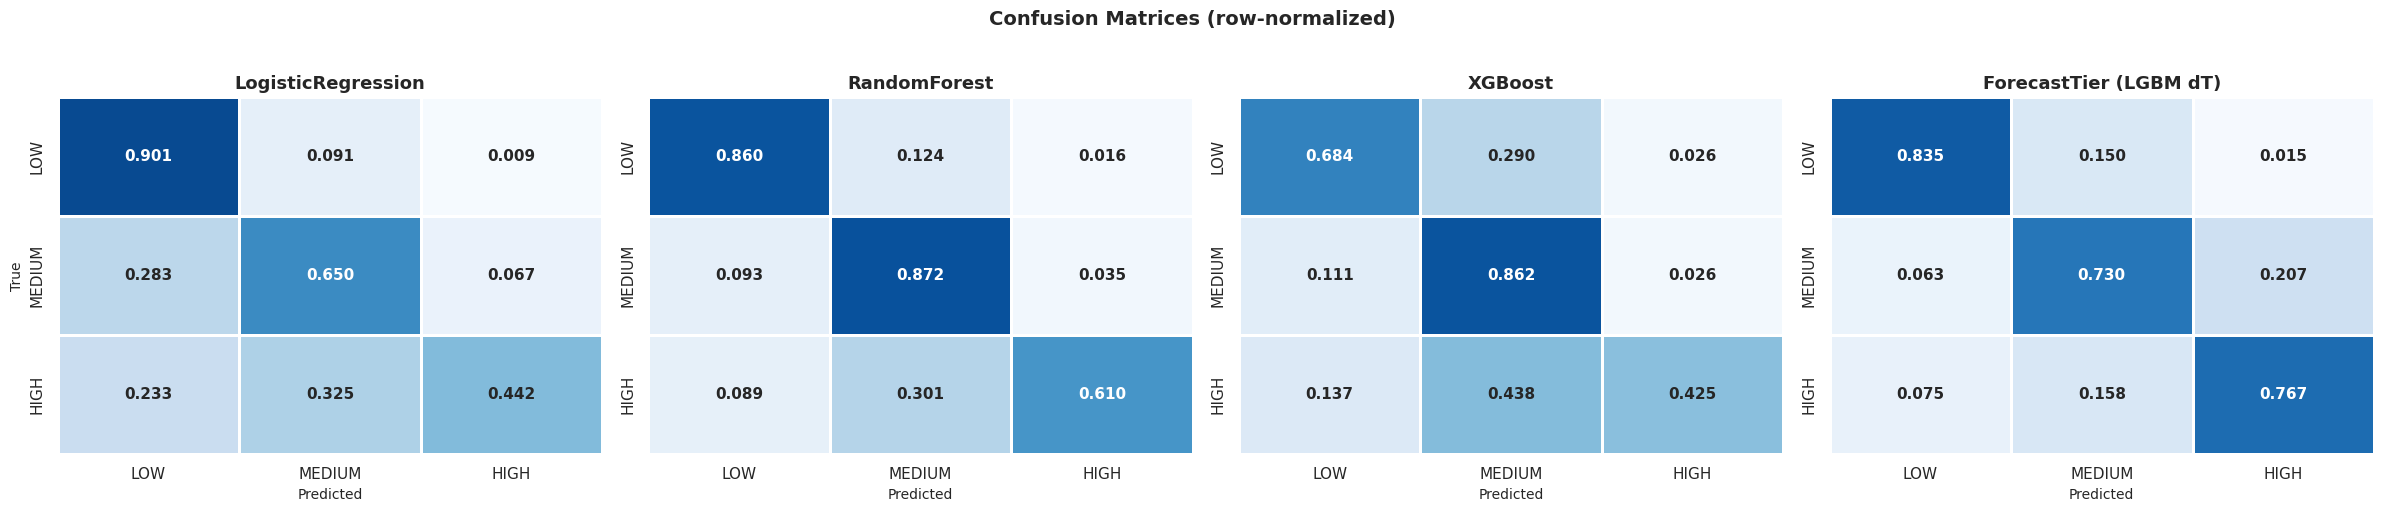

In [30]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
if n_models == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, models.items()):
    preds = np.asarray(m.predict(X_test)).astype(int)
    cm = confusion_matrix(y_test, preds, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".3f", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                vmin=0, vmax=1, cbar=False, linewidths=1, linecolor="white",
                annot_kws={"fontsize": 11, "fontweight": "bold"}, ax=ax)
    ax.set_title(f"{name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True" if name == list(models.keys())[0] else "")

plt.suptitle("Confusion Matrices (row-normalized)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("confusion_matrices")
plt.show()

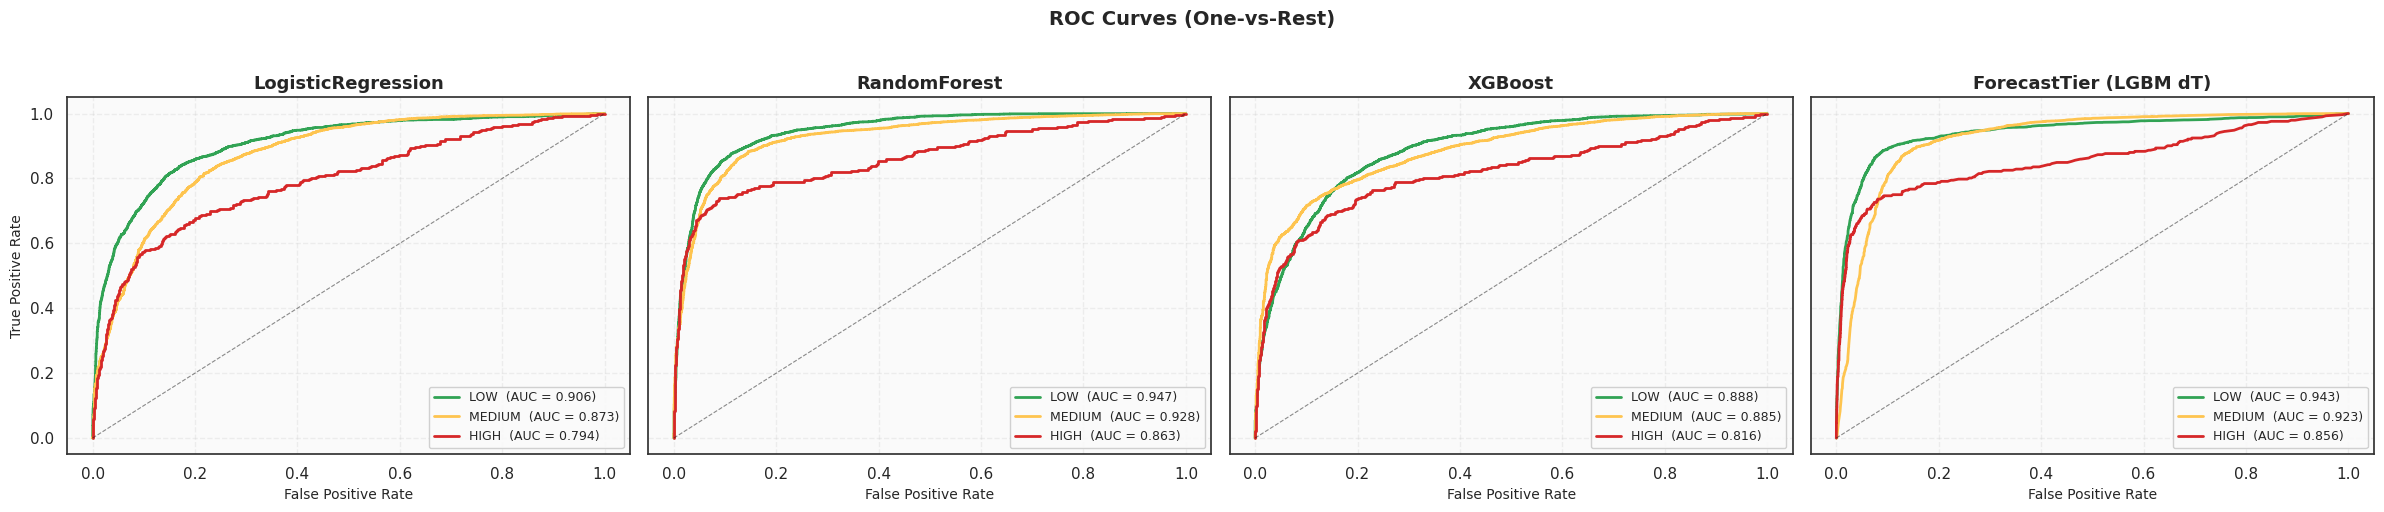

In [31]:
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, models.items()):
    proba = m.predict_proba(X_test)
    for i, cls in enumerate(CLASS_NAMES):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
        auc_i = roc_auc_score(y_test_bin[:, i], proba[:, i])
        ax.plot(fpr, tpr, lw=2, color=CLASS_COLORS[i],
                label=f"{cls}  (AUC = {auc_i:.3f})")
    ax.plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
    ax.set_title(f"{name}")
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate" if name == list(models.keys())[0] else "")
    ax.legend(loc="lower right", fontsize=9)

plt.suptitle("ROC Curves (One-vs-Rest)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("roc_curves")
plt.show()

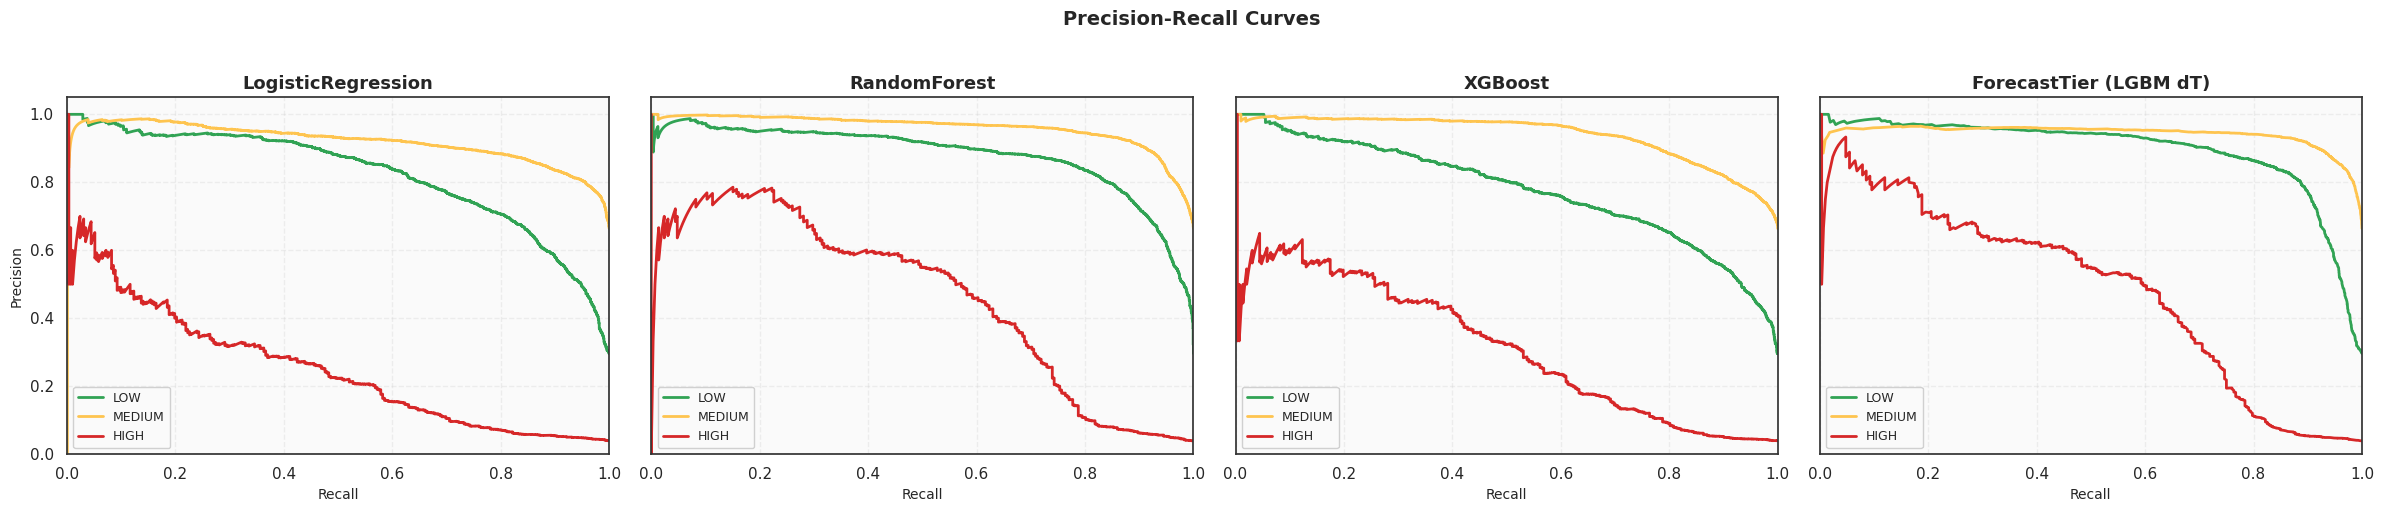

In [32]:
n_models = len(models)
fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5), sharey=True)
if n_models == 1:
    axes = [axes]

for ax, (name, m) in zip(axes, models.items()):
    proba = m.predict_proba(X_test)
    for i, cls in enumerate(CLASS_NAMES):
        prec, rec, _ = precision_recall_curve(y_test_bin[:, i], proba[:, i])
        ax.plot(rec, prec, lw=2, color=CLASS_COLORS[i], label=cls)
    ax.set_title(f"{name}")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision" if name == list(models.keys())[0] else "")
    ax.legend(loc="lower left", fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)

plt.suptitle("Precision-Recall Curves", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
save_fig("precision_recall")
plt.show()

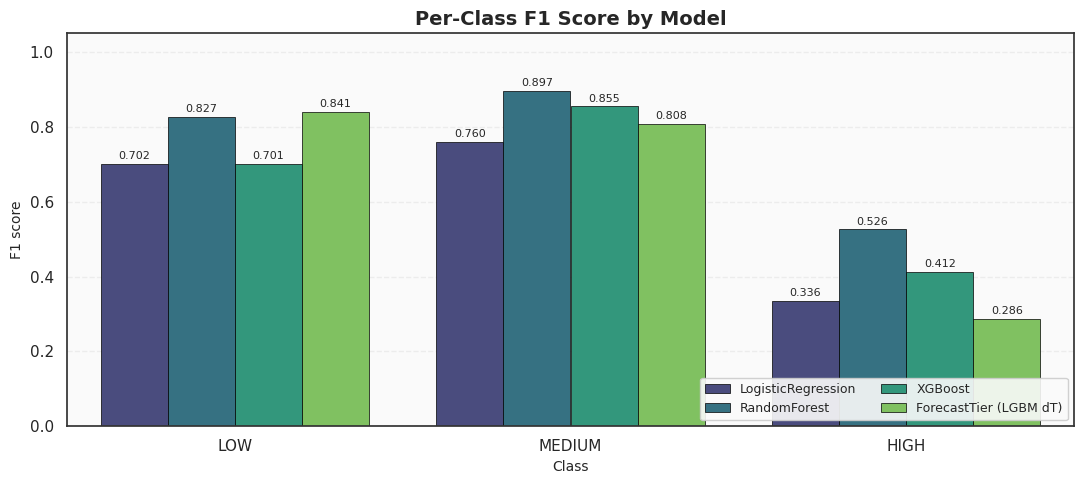

Class                    HIGH    LOW  MEDIUM
Model                                       
ForecastTier (LGBM dT)  0.286  0.841   0.808
LogisticRegression      0.336  0.702   0.760
RandomForest            0.526  0.827   0.897
XGBoost                 0.412  0.701   0.855


In [33]:
rows = []
for name, m in models.items():
    preds = np.asarray(m.predict(X_test)).astype(int)
    f1_per = f1_score(y_test, preds, average=None)
    for i, cls in enumerate(CLASS_NAMES):
        rows.append({"Model": name, "Class": cls, "F1": f1_per[i]})

f1_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=f1_df, x="Class", y="F1", hue="Model",
            palette="viridis", edgecolor="black", linewidth=0.5, ax=ax)
ax.set_ylim(0, 1.05)
ax.set_title("Per-Class F1 Score by Model", fontsize=14, fontweight="bold")
ax.set_ylabel("F1 score")
for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=8, padding=2)
ax.legend(loc="lower right", ncol=2, fontsize=9)
plt.tight_layout()
save_fig("per_class_f1")
plt.show()

print(f1_df.pivot(index="Model", columns="Class", values="F1").round(3))

In [34]:
print(f"Best classifier (macro-F1): {best_name}\n")
preds = np.asarray(clf.predict(X_test)).astype(int)
print(classification_report(y_test, preds,
                            target_names=CLASS_NAMES, digits=4))

Best classifier (macro-F1): ForecastTier (LGBM dT)

              precision    recall  f1-score   support

         LOW     0.8463    0.8355    0.8408      2194
      MEDIUM     0.9053    0.7296    0.8080      4915
        HIGH     0.1758    0.7671    0.2861       292

    accuracy                         0.7625      7401
   macro avg     0.6425    0.7774    0.6450      7401
weighted avg     0.8590    0.7625    0.7972      7401



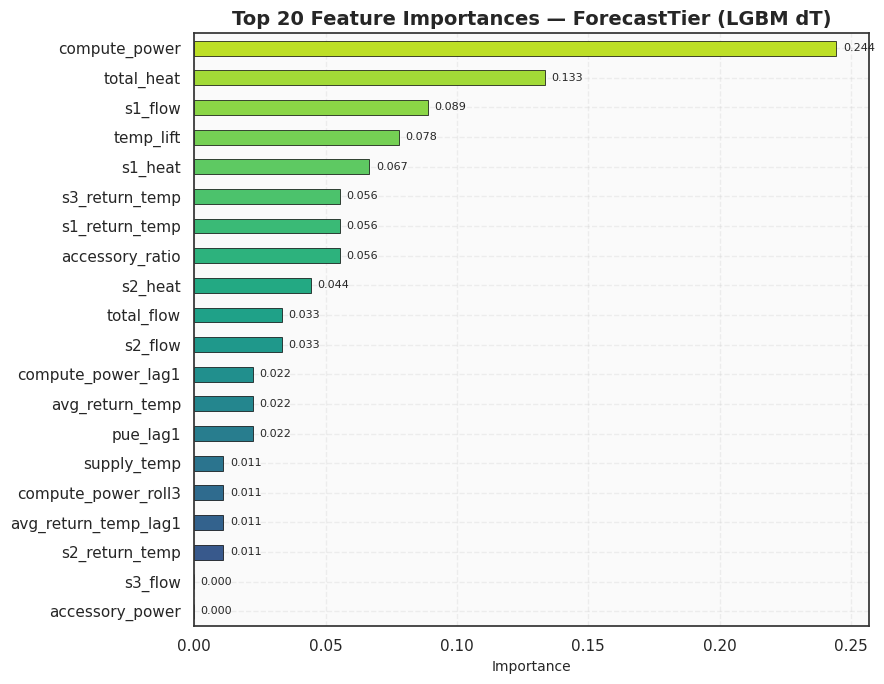

In [35]:
imp = pd.Series(clf.feature_importances_, index=feature_cols)
imp = imp.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(9, 7))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp)))[::-1]
imp.plot(kind="barh", ax=ax, color=colors, edgecolor="black", linewidth=0.5)
ax.invert_yaxis()
ax.set_xlabel("Importance")
ax.set_title(f"Top 20 Feature Importances — {best_name}", fontsize=14, fontweight="bold")
for i, v in enumerate(imp.values):
    ax.text(v + max(imp)*0.01, i, f"{v:.3f}", va="center", fontsize=8)
plt.tight_layout()
save_fig("feature_importance")
plt.show()


print(f"\nLightGBM best iteration: {clf.reg.best_iteration_}")
print(f"Interpretation: model stopped improving after {clf.reg.best_iteration_} trees.")
print(f"This indicates the features contain little incremental signal beyond persistence.")

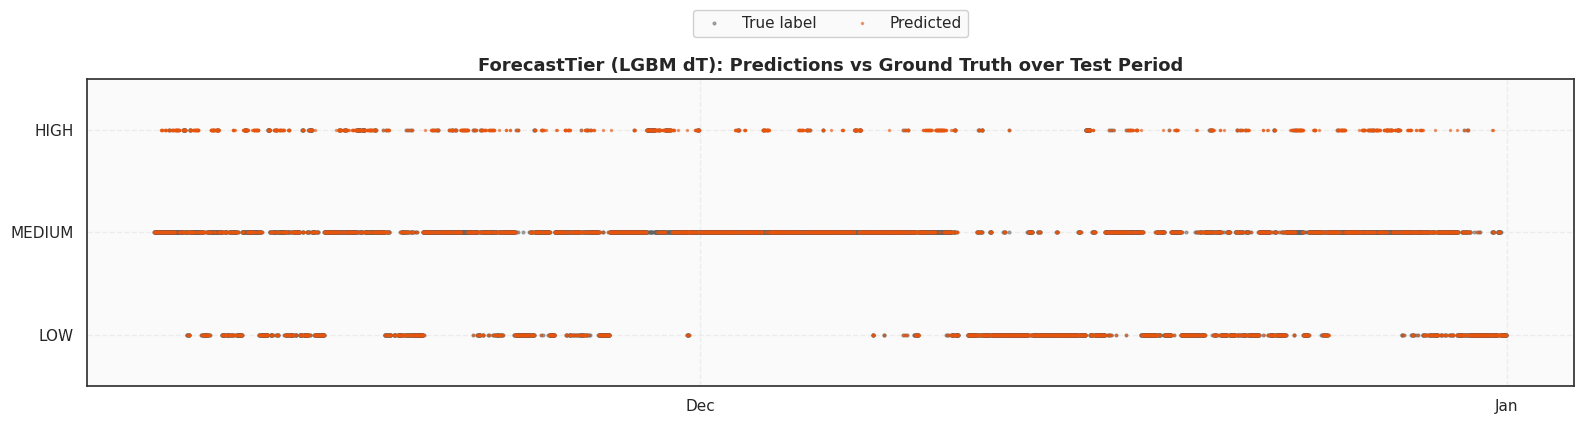

In [36]:
preds = np.asarray(clf.predict(X_test)).astype(int)

fig, ax = plt.subplots(figsize=(16, 4.5))
test_times = test_r["timestamp"].values
ax.plot(test_times, y_test, ".", ms=4, color=PALETTE["neutral"],
        label="True label", alpha=0.5)
ax.plot(test_times, preds, ".", ms=3, color=PALETTE["accent"],
        label="Predicted", alpha=0.5)

ax.set_yticks([0, 1, 2]); ax.set_yticklabels(CLASS_NAMES)
ax.set_ylim(-0.5, 2.5)
ax.set_title(f"{best_name}: Predictions vs Ground Truth over Test Period")
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b"))
ax.legend(loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.25))
plt.tight_layout()
save_fig("predictions_over_time")
plt.show()

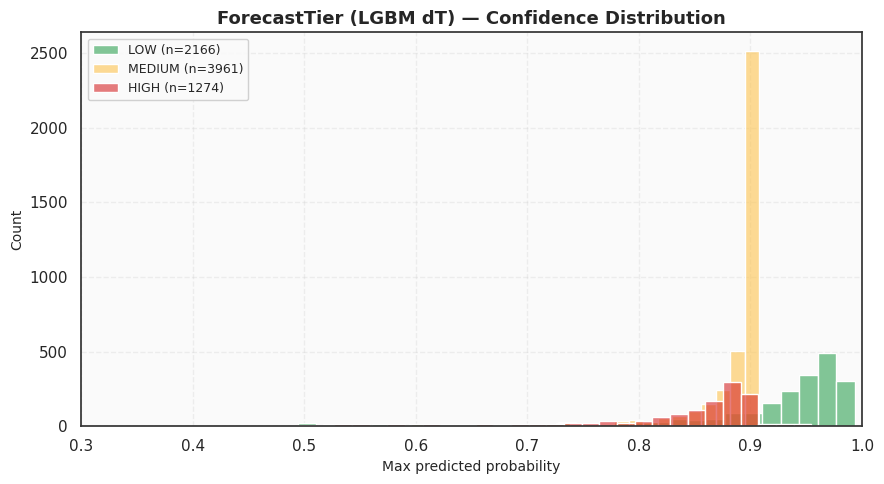

In [37]:
proba = clf.predict_proba(X_test)
preds = np.asarray(clf.predict(X_test)).astype(int)
max_proba = proba.max(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))
for i, cls in enumerate(CLASS_NAMES):
    mask = preds == i
    if mask.sum():
        sns.histplot(max_proba[mask], bins=30, ax=ax,
                     color=CLASS_COLORS[i], label=f"{cls} (n={mask.sum()})",
                     alpha=0.6, edgecolor="white")
ax.set_xlabel("Max predicted probability")
ax.set_title(f"{best_name} — Confidence Distribution")
ax.set_xlim(0.3, 1.0)
ax.legend(fontsize=9)
plt.tight_layout()
save_fig("confidence_distribution")
plt.show()

errors by distance of true T(t+1) to nearest threshold (degC):
                 rows  errors  error_rate  share_of_errors
bin                                                      
(-0.001, 0.25]   344     170       0.494            0.097
(0.25, 0.5]      369     202       0.547            0.115
(0.5, 1.0]       859     407       0.474            0.232
(1.0, 2.0]      2896     737       0.254            0.419
(2.0, 5.0]      2795     239       0.086            0.136
(5.0, inf]       138       3       0.022            0.002

errors 1758 of 7401 (23.75%)
HIGH->LOW: 22 of 292 (7.53%)
missed HIGH rows: 68 | median degC above 35: 0.83

error cross-tab (errors only):
 pred    HIGH  LOW  MEDIUM
true                     
HIGH       0   22      46
LOW       32    0     329
MEDIUM  1018  311       0


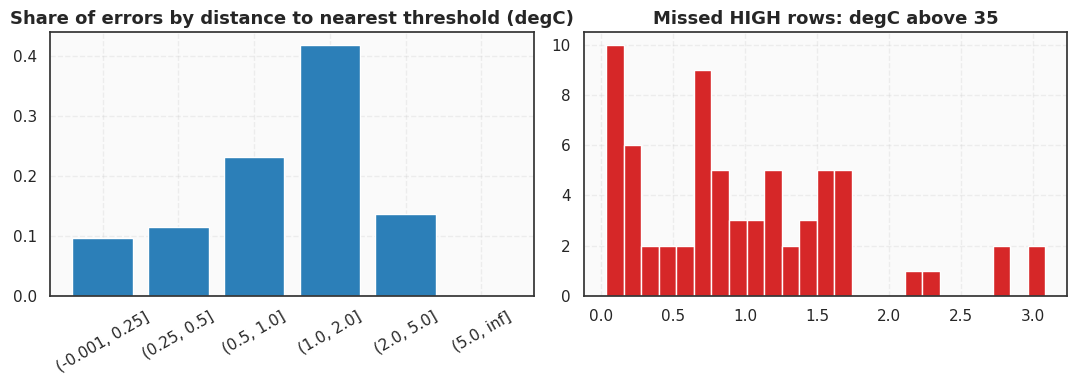

In [38]:
p, y, T = REG[best_name]["pred"], y_test, T_nxt["test"]
err = p != y
h = y == 2
miss = h & (p != 2)

dist = np.minimum(np.abs(T - LOW_THRESH), np.abs(T - HIGH_THRESH))
bins = pd.cut(dist, [0, .25, .5, 1, 2, 5, np.inf], include_lowest=True)
tab = (pd.DataFrame({"bin": bins, "err": err})
         .groupby("bin", observed=True)
         .agg(rows=("err", "size"), errors=("err", "sum")))
tab["error_rate"]      = tab.errors / tab.rows
tab["share_of_errors"] = tab.errors / max(err.sum(), 1)

print("errors by distance of true T(t+1) to nearest threshold (degC):\n", tab.round(3))
print(f"\nerrors {err.sum()} of {len(y)} ({err.mean():.2%})")
print(f"HIGH->LOW: {((p == 0) & h).sum()} of {h.sum()} "
      f"({((p == 0) & h).sum() / max(h.sum(), 1):.2%})")
if miss.any():
    ex = T[miss] - HIGH_THRESH
    print(f"missed HIGH rows: {miss.sum()} | median degC above {HIGH_THRESH:.0f}: "
          f"{np.median(ex):.2f}")

lab = dict(enumerate(CLASS_NAMES))
print("\nerror cross-tab (errors only):\n",
      pd.crosstab(pd.Series(y[err], name="true").map(lab),
                  pd.Series(p[err], name="pred").map(lab)))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].bar(range(len(tab)), tab.share_of_errors, color=PALETTE["primary"])
ax[0].set_xticks(range(len(tab)))
ax[0].set_xticklabels([str(i) for i in tab.index], rotation=30)
ax[0].set_title("Share of errors by distance to nearest threshold (degC)")
if miss.any():
    ax[1].hist(T[miss] - HIGH_THRESH, bins=25, color=PALETTE["danger"])
    ax[1].set_title("Missed HIGH rows: degC above 35")
plt.tight_layout()
save_fig("error_analysis")
plt.show()

In [41]:
s = scores(y_test, REG[best_name]["pred"])
ev = ext_tbl.loc[best_name]
cm = cmp_tbl.loc[best_name]
pe = cmp_tbl.loc["persistence"]

card = {
    "thresholds_degC": [LOW_THRESH, HIGH_THRESH],
    "feature_set": f"{FINAL_VARIANT} ({len(clf.cols)})",
    "margin_degC": clf.margin,
    "target_recall (val-B)": TARGET_RECALL,
    "val-B recall": float(r.recall),
    "val-B precision": float(r.precision),
    "test accuracy": s["acc"],
    "test balanced acc": s["bal_acc"],
    "test macro-F1": s["macro_F1"],
    "test HIGH recall": s["HIGH_recall"],
    "test HIGH recall CI95": ev["HIGH_recall_CI95"],
    "test HIGH precision": s["HIGH_prec"],
    "test HIGH->LOW": s["HIGH_to_LOW"],
    "test HIGH AUC / AP": f"{cm.HIGH_AUC:.3f} / {cm.HIGH_AP:.3f}",
    "HIGH episodes / detected": f"{int(ev.n_episodes)} / {ev.episode_detect:.0%}",
    "first-row detection": ev.first_row_detect,
    "onset recall": ev.HIGH_onset_recall,
    "forecast MAE vs persistence (degC)": f"{mae:.3f} vs {mae_p:.3f}",
    "persistence acc / bal-acc": f"{pe.acc:.3f} / {pe.bal_acc:.3f}",
}

print("=" * 70)
print("COOLANT THERMAL-RISK CLASSIFIER (test window)")
print("=" * 70)
for k, v in card.items():
    print(f"{k:<36s} {v:.3f}" if isinstance(v, (float, np.floating)) else f"{k:<36s} {v}")

json.dump({k: (float(v) if isinstance(v, (float, np.floating)) else v) for k, v in card.items()},
          open(MODEL_DIR / "coolant_tier_summary.json", "w"), indent=2)


card["forecast skill vs persistence"] = f"{1 - mae/mae_p:+.2%}"
card["forecast beats persistence (MAE)"] = "no" if mae >= mae_p else "yes"

COOLANT THERMAL-RISK CLASSIFIER (test window)
thresholds_degC                      [30.0, 35.0]
feature_set                          no_calendar (36)
margin_degC                          1.700
target_recall (val-B)                0.800
val-B recall                         0.800
val-B precision                      0.273
test accuracy                        0.762
test balanced acc                    0.777
test macro-F1                        0.645
test HIGH recall                     0.767
test HIGH recall CI95                [0.64, 0.85]
test HIGH precision                  0.176
test HIGH->LOW                       0.075
test HIGH AUC / AP                   0.856 / 0.484
HIGH episodes / detected             132 / 66%
first-row detection                  0.485
onset recall                         0.485
forecast MAE vs persistence (degC)   0.831 vs 0.822
persistence acc / bal-acc            0.876 / 0.767


In [42]:
clf.reg.booster_.save_model(str(MODEL_DIR / "coolant_tier_lgbm.txt"))
np.save(MODEL_DIR / "coolant_tier_val_residuals.npy", clf.res)

meta = dict(
    task="forecast T(t+1)-T(t) in degC, threshold to tiers",
    thresholds=dict(low=LOW_THRESH, high=HIGH_THRESH),
    margin_degC=clf.margin,
    target_recall=TARGET_RECALL,
    calibration="val odd days (IDX_B)",
    selection="val even days (IDX_A)",
    variant=FINAL_VARIANT,
    features=clf.cols,
    current_temp_col="avg_return_temp",
    degC_affine=dict(a=A_C, b=B_C, how=HOW),
    best_iteration=int(clf.reg.best_iteration_),
    seed=42,
    lgbm_params=clf.reg.get_params(),
    versions=dict(lightgbm=lgb.__version__, numpy=np.__version__, pandas=pd.__version__),
)
json.dump(meta, open(MODEL_DIR / "coolant_tier_meta.json", "w"), indent=2, default=str)

bst = lgb.Booster(model_file=str(MODEL_DIR / "coolant_tier_lgbm.txt"))
dmax = np.abs(bst.predict(X_test[clf.cols].values) - clf.reg.predict(X_test[clf.cols].values)).max()
print(f"reload check max |diff| = {dmax:.2e}")
assert dmax < 1e-6

print("✓ Saved:")
print(f"   {MODEL_DIR}/coolant_tier_lgbm.txt")
print(f"   {MODEL_DIR}/coolant_tier_val_residuals.npy")
print(f"   {MODEL_DIR}/coolant_tier_meta.json")
print(f"   {MODEL_DIR}/coolant_tier_summary.json")

reload check max |diff| = 0.00e+00
✓ Saved:
   ../models/coolant_tier_lgbm.txt
   ../models/coolant_tier_val_residuals.npy
   ../models/coolant_tier_meta.json
   ../models/coolant_tier_summary.json
